In [2]:
# imports
import okex
from tardis.lib import pandas_utils as pu
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
import polars as pl

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

execute = False
execute = True

recreate_pcpb_data = False

In [2]:

def recompute_pcpb(day):
    from okex import merge_data, mark_up_with_futures, align_calls_puts, pcp_breaking_polars, datadir
    # day can be a filename
    day = day.replace(f'{datadir}/okex-options_prod5_','').replace('_5min.parquet','')
    day = day.replace(f'{datadir}/okex_pcpb_prod5_','').replace('.parquet','')
    day = pd.Timestamp(day)
    resampled_df = merge_data(day, freq='5min', output_tag='prod5',
                              force_reload=False, cleanup=False)
    opt_df, _ = mark_up_with_futures(resampled_df)
    opt_df_aligned = align_calls_puts(opt_df)
    pcpb = pcp_breaking_polars(opt_df_aligned)
    pcpb.write_parquet(f'{datadir}/okex_pcpb_prod5_{day.date()}.parquet')


    cols_needed = [
        "amu_fwd_bp", "call_opt_spread_bp", "amu_bck_bp", "put_opt_spread_bp",
        "ref_sym", "tte", "strike", "index", "call_stale", "put_stale", 'ts',
        "fut_mid_price", "mdy", "rel_strike"
    ]
    # Only keep columns that exist in the DataFrame
    cols_to_return = [c for c in cols_needed if c in pcpb.columns]
    return pcpb.select(cols_to_return)


def load_pcpb_data():
    # read in ready parquet files
    files = sorted(Path("okex").glob("okex-options_prod5_*_5min.parquet"))
    if not files:
        raise FileNotFoundError("No files matched: okex/okex_pcpb_prod5_*.parquet")

    #for f in files:
    #    pd.read_parquet(f)

    if not recreate_pcpb_data:
        pcpb_polars = pl.read_parquet("okex/pcpb_all.parquet")
    else:
        pcpb_polars = pl.concat([recompute_pcpb(str(f)) for f in files])
        pcpb_polars.write_parquet("okex/pcpb_all.parquet")

    return pcpb_polars

pcpb_polars = None
if execute:
    pcpb_polars = load_pcpb_data()

In [3]:
def summarize_options_sample(
    pcpb_polars,
    target_date=pd.Timestamp("2025-02-02").date(),
    rel_strike_min=0.7,
    rel_strike_max=1.5,
):
    df = pcpb_polars.with_columns(
        [
            pl.col("ref_sym").cast(pl.Utf8).str.split("-").list.first().alias("asset"),
            pl.col("ts").cast(pl.Datetime("us")).dt.date().alias("day"),
        ]
    )

    call_spread_col = next((c for c in ["call_opt_spread", "call_opt_spread_bp"] if c in df.columns), None)
    put_spread_col = next((c for c in ["put_opt_spread", "put_opt_spread_bp"] if c in df.columns), None)
    expiry_col = next((c for c in ["expiration", "expiry", "exp_date", "expiration_date"] if c in df.columns), None)

    metrics = [
        "num_options_contracts_on_2025_02_02",
        "num_expirations_on_2025_02_02",
        "num_strikes_on_2025_02_02",
        "num_5min_slices_on_2025_02_02",
        "num_days_in_sample",
        "mean_call_opt_spread_bp_rel_strike_0.7_to_1.5",
        "mean_put_opt_spread_bp_rel_strike_0.7_to_1.5",
    ]

    out = {}

    for asset in ["ETH", "BTC"]:
        sub = df.filter(pl.col("asset") == asset)
        sub_day = sub.filter(pl.col("day") == target_date)

        # Use first 5-min slice of the target day as "available contracts/strikes/expirations"
        if sub_day.height > 0:
            first_ts = sub_day.select(pl.col("ts").min()).item()
            snap = sub_day.filter(pl.col("ts") == first_ts)
        else:
            snap = sub_day

        # Options contracts count (prefer explicit symbols if available; fallback to 2 * unique (tte, strike))
        if {"call_symbol", "put_symbol"}.issubset(set(snap.columns)):
            call_n = snap.select(pl.col("call_symbol").n_unique()).item()
            put_n = snap.select(pl.col("put_symbol").n_unique()).item()
            num_contracts = int(call_n + put_n)
        elif "symbol" in snap.columns:
            num_contracts = int(snap.select(pl.col("symbol").n_unique()).item())
        elif {"tte", "strike"}.issubset(set(snap.columns)):
            pair_n = snap.select(pl.struct(["tte", "strike"]).n_unique()).item()
            num_contracts = int(2 * pair_n)
        else:
            num_contracts = np.nan

        # Expirations count
        if expiry_col is not None:
            num_expirations = int(snap.select(pl.col(expiry_col).n_unique()).item()) if snap.height else 0
        elif "tte" in snap.columns:
            num_expirations = int(snap.select(pl.col("tte").round(8).n_unique()).item()) if snap.height else 0
        else:
            num_expirations = np.nan

        # Strikes count
        num_strikes = int(snap.select(pl.col("strike").n_unique()).item()) if "strike" in snap.columns and snap.height else 0

        # Number of 5-minute slices on target day
        num_slices = int(sub_day.select(pl.col("ts").n_unique()).item()) if sub_day.height else 0

        # Number of days in sample
        num_days = int(sub.select(pl.col("day").n_unique()).item()) if sub.height else 0

        # Mean spreads over sample, filtered by relative strike window
        if "rel_strike" in sub.columns:
            spread_base = sub.filter(
                (pl.col("rel_strike") >= rel_strike_min) & (pl.col("rel_strike") <= rel_strike_max)
            )
        else:
            spread_base = sub

        mean_call = float(spread_base.select(pl.col(call_spread_col).mean()).item()) if call_spread_col else np.nan
        mean_put = float(spread_base.select(pl.col(put_spread_col).mean()).item()) if put_spread_col else np.nan

        out[asset] = [
            num_contracts,
            num_expirations,
            num_strikes,
            num_slices,
            num_days,
            mean_call,
            mean_put,
        ]

    return pd.DataFrame(out, index=metrics)


summary_df = None
summary_df_display = None
if execute and pcpb_polars is not None:
    summary_df = summarize_options_sample(pcpb_polars)
    summary_df_display = summary_df.round(0).astype("Int64")

display(summary_df_display)
if summary_df_display is not None:
    import matplotlib.pyplot as plt

    fig_h = max(2.5, 0.45 * (len(summary_df_display.index) + 1))
    fig_w = max(6, 1.8 * (len(summary_df_display.columns) + 1))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    tbl = ax.table(
        cellText=summary_df_display.values,
        rowLabels=summary_df_display.index.tolist(),
        colLabels=summary_df_display.columns.tolist(),
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.2)

    output_png = "publications/summary_df_display.png"
    plt.tight_layout()
    plt.savefig(output_png, dpi=200, bbox_inches="tight")
    plt.close(fig)

    output_png


,ETH,BTC
num_options_contracts_on_2025_02_02,260,326
num_expirations_on_2025_02_02,4,6
num_strikes_on_2025_02_02,56,52
num_5min_slices_on_2025_02_02,288,288
num_days_in_sample,404,404
mean_call_opt_spread_bp_rel_strike_0.7_to_1.5,100,2704
mean_put_opt_spread_bp_rel_strike_0.7_to_1.5,470,1216


In [3]:
def mark_up_pcpb(df):
    # expects a polars DataFrame
    return df.with_columns([
        (pl.col("amu_fwd_bp") + pl.col("call_opt_spread_bp")).alias("fwd_call"),
        (pl.col("amu_fwd_bp") + pl.col("put_opt_spread_bp")).alias("fwd_put"),
        (pl.col("amu_bck_bp") + pl.col("call_opt_spread_bp")).alias("bck_call"),
        (pl.col("amu_bck_bp") + pl.col("put_opt_spread_bp")).alias("bck_put"),
    ])

pcpb = None
if execute and pcpb_polars is not None:
    pcpb = mark_up_pcpb(pcpb_polars).to_pandas()
    pcpb = pcpb.loc[pcpb.ts > '2025-01-01']

In [ ]:
def calculate_amu_bps(pcpb, max_bp_cutoff=100):
    fresh_idx =((~pcpb.call_stale)&(~pcpb.put_stale))|True
    pcpb_fresh = pcpb.loc[fresh_idx]

    join_call_ask_bp = float(pcpb_fresh.fwd_call.clip(lower=0, upper=max_bp_cutoff).mean())
    join_call_bid_bp = float(pcpb_fresh.bck_call.clip(lower=0, upper=max_bp_cutoff).mean())
    join_put_ask_bp = float(pcpb_fresh.bck_put.clip(lower=0, upper=max_bp_cutoff).mean())
    join_put_bid_bp = float(pcpb_fresh.fwd_put.clip(lower=0, upper=max_bp_cutoff).mean())
    join_call_ask_num = int((pcpb_fresh["fwd_call"] > 0).sum())
    join_call_bid_num = int((pcpb_fresh["bck_call"] > 0).sum())
    join_put_ask_num = int((pcpb_fresh["bck_put"] > 0).sum())
    join_put_bid_num = int((pcpb_fresh["fwd_put"] > 0).sum())
    amu_num = join_call_ask_num + join_call_bid_num + join_put_ask_num + join_put_bid_num

    weighted_sum = (
        join_call_ask_bp * join_call_ask_num
        + join_call_bid_bp * join_call_bid_num
        + join_put_ask_bp * join_put_ask_num
        + join_put_bid_bp * join_put_bid_num
    )

    weighted_avg = weighted_sum / amu_num if amu_num > 0 else np.nan
    return weighted_avg, amu_num, len(pcpb_fresh)

amu_num = amu_bps = num_pairs = None
if execute and pcpb is not None:
    amu_bps, amu_num, num_pairs = calculate_amu_bps(pcpb)



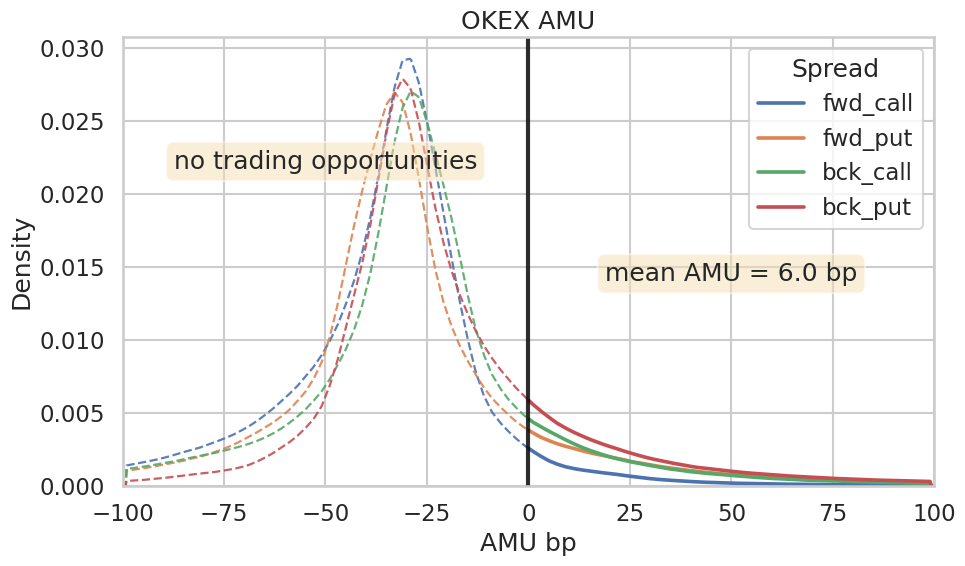

In [ ]:
def plot_4_spreads(
    pcpb,
    rng=100,
    smoothed=False,
    filename="okex_plot_4_spreads.png",
    title="OKEX AMU",
):
    sns.set_theme(style="whitegrid", context="talk")
    cols = ["fwd_call", "fwd_put", "bck_call", "bck_put"]
    colors = sns.color_palette("deep", n_colors=len(cols))
    fig, ax = plt.subplots(figsize=(10, 6))
    visible_max = 0.0

    for col, color in zip(cols, colors):
        vals = pd.to_numeric(pcpb[col], errors="coerce").to_numpy()
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue

        counts, edges = np.histogram(vals, bins=100, range=(-rng, rng), density=True)
        visible_max = max(visible_max, float(np.nanmax(counts)) if counts.size else 0.0)

        if smoothed:
            centers = 0.5 * (edges[:-1] + edges[1:])
            x_fine = np.linspace(-rng, rng, 800)
            y_fine = np.interp(x_fine, centers, counts, left=0.0, right=0.0)

            left_mask = x_fine < 0
            right_mask = x_fine >= 0

            ax.plot(
                x_fine[left_mask],
                y_fine[left_mask],
                color=color,
                linestyle="--",
                linewidth=1.6,
                alpha=0.9,
            )
            ax.plot(
                x_fine[right_mask],
                y_fine[right_mask],
                color=color,
                linestyle="-",
                linewidth=2.6,
                alpha=1.0,
                label=col,
            )
        else:
            sns.histplot(
                vals,
                bins=100,
                binrange=(-rng, rng),
                stat="density",
                element="step",
                fill=False,
                common_norm=False,
                ax=ax,
                label=col,
                linewidth=1.6,
                color=color,
            )

    ax.axvline(0, color="black", linestyle="-", linewidth=3.0, alpha=0.8)
    ax.set_xlim(-rng, rng)
    ax.set_ylim(0, visible_max * 1.05 if visible_max > 0 else 1.0)
    ax.set_xlabel("AMU bp")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend(title="Spread")

    amu_text, _, _ = calculate_amu_bps(pcpb)
    ax.text(
        0.75,
        0.5,
        f"mean AMU = {amu_text:.1f} bp",
        transform=ax.transAxes,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
        va="top",
        ha="center",
    )

    ax.text(
        0.25,
        0.75,
        f"no trading opportunities",
        transform=ax.transAxes,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
        va="top",
        ha="center",
    )

    fig.tight_layout()
    fig.savefig(filename)
    return fig, ax

fig = ax = None
if execute and pcpb is not None:
    fig, ax = plot_4_spreads(pcpb, smoothed=True, filename='publications/okex_4_spreads.png')

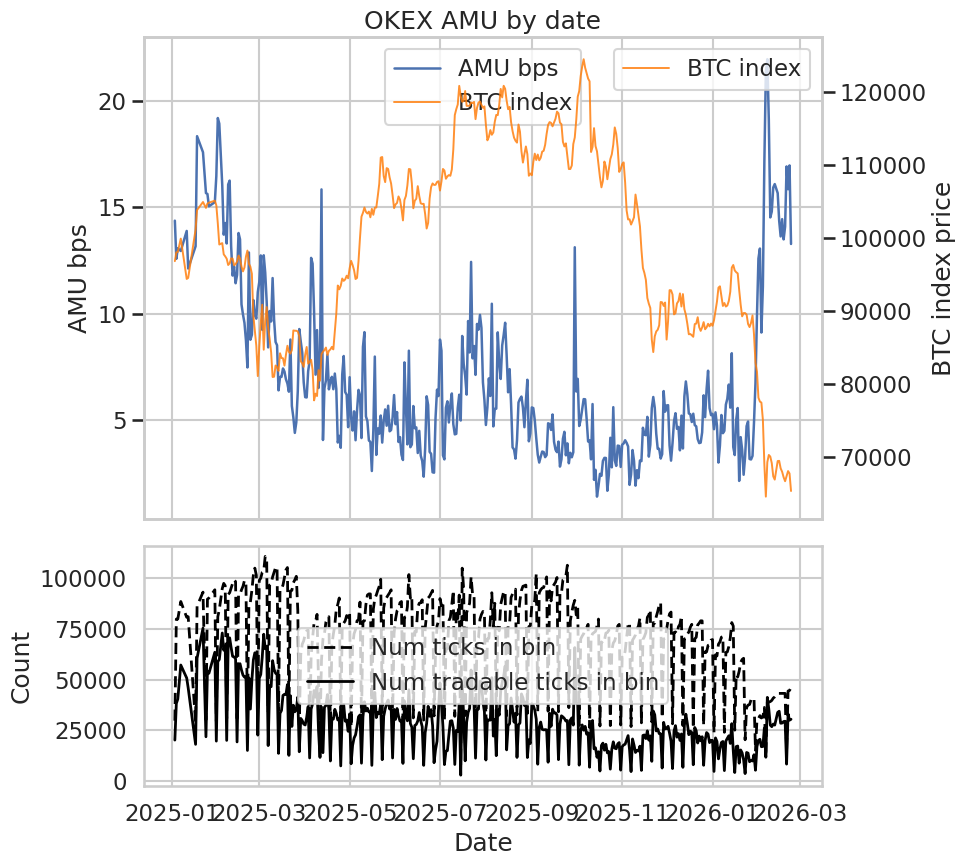

In [ ]:
def plot_amu_bps_by_date(
    pcpb,
    max_bp_cutoff=100,
    filename="okex_amu_bps_by_date.png",
    title = 'OKEX AMU by date'
):
    daily_amu_bps = (
        pcpb.groupby("mdy", sort=True)
        .apply(
            lambda g: pd.Series(
                calculate_amu_bps(g, max_bp_cutoff=max_bp_cutoff),
                index=["amu_bps", "num_amu", "num_pairs"],
            )
        )
        .reset_index()
        .sort_values("mdy")
    )

    counts_long = daily_amu_bps[["mdy", "num_amu", "num_pairs"]].melt(
        id_vars="mdy",
        value_vars=["num_amu", "num_pairs"],
        var_name="metric",
        value_name="count",
    )
    counts_long["metric"] = counts_long["metric"].map(
        {
            "num_amu": "Num tradable ticks in bin",
            "num_pairs": "Num ticks in bin",
        }
    )

    btc_daily_index = (
        pcpb.loc[pcpb["ref_sym"] == "BTC-USD", ["mdy", "index"]]
        .groupby("mdy", sort=True)["index"]
        .mean()
        .reset_index()
    )

    sns.set_theme(style="whitegrid", context="talk")
    fig, (ax_top, ax_bottom) = plt.subplots(
        2,
        1,
        figsize=(10, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
    )

    sns.lineplot(
        data=daily_amu_bps,
        x="mdy",
        y="amu_bps",
        marker=None,
        linewidth=1.8,
        ax=ax_top,
        label="AMU bps",
    )

    ax_top2 = ax_top.twinx()
    sns.lineplot(
        data=btc_daily_index,
        x="mdy",
        y="index",
        color="tab:orange",
        linewidth=1.4,
        alpha=0.85,
        ax=ax_top2,
        label="BTC index",
    )
    ax_top2.grid(False)
    ax_top2.set_ylabel("BTC index price")

    lines, labels = ax_top.get_legend_handles_labels()
    lines2, labels2 = ax_top2.get_legend_handles_labels()
    ax_top.legend(lines + lines2, labels + labels2, loc="best")

    ax_top.set_ylabel("AMU bps")
    ax_top.set_title(title)

    sns.lineplot(
        data=counts_long,
        x="mdy",
        y="count",
        hue="metric",
        style="metric",
        linewidth=2.0,
        palette={
            "Num tradable ticks in bin": "black",
            "Num ticks in bin": "black",
        },
        dashes={
            "Num tradable ticks in bin": "",
            "Num ticks in bin": (4, 2),
        },
        ax=ax_bottom,
    )
    ax_bottom.set_xlabel("Date")
    ax_bottom.set_ylabel("Count")
    handles, labels = ax_bottom.get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))
    ordered_labels = ["Num ticks in bin", "Num tradable ticks in bin"]
    ordered_handles = [label_to_handle[label] for label in ordered_labels if label in label_to_handle]
    ax_bottom.legend(ordered_handles, ordered_labels, title="")

    fig.tight_layout()
    fig.savefig(filename)
    return daily_amu_bps, fig, (ax_top, ax_bottom), counts_long


daily_amu_bps = daily_fig = daily_axes = None
if execute and pcpb is not None:
    daily_amu_bps, daily_fig, daily_axes, counts_long = plot_amu_bps_by_date(
        pcpb,
        filename="publications/okex_amu_bps_by_date.png",
    )

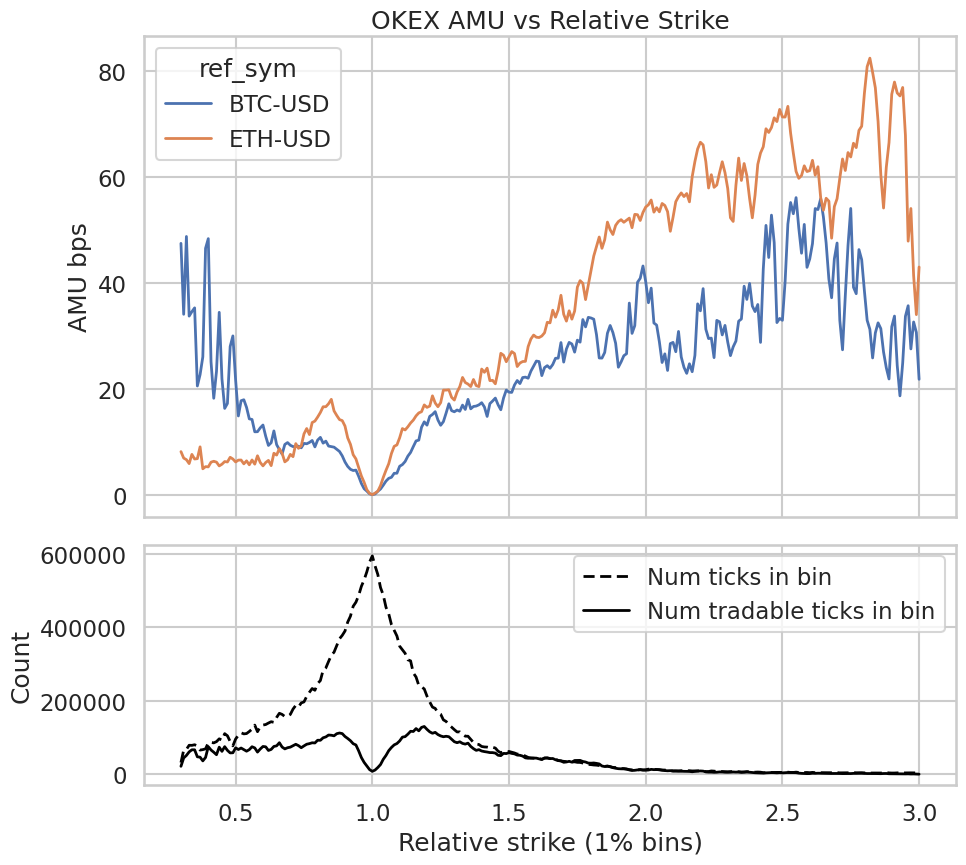

In [ ]:
def plot_amu_bps_by_rel_strike(
    pcpb,
    max_bp_cutoff=100,
    rel_strike_from=0.3,
    rel_strike_to=3.0,
    filename="publications/okex_amu_bps_by_rel_strike.png",
    title="OKEX AMU bps vs Relative Strike",
):
    bin_size = 0.01  # 1% bins

    curve_df = (
        pcpb.dropna(subset=["ref_sym", "rel_strike"])
        .assign(rel_strike=lambda d: pd.to_numeric(d["rel_strike"], errors="coerce"))
        .dropna(subset=["rel_strike"])
        .loc[lambda d: d["rel_strike"].between(rel_strike_from, rel_strike_to)]
        .assign(rel_strike_bin=lambda d: (d["rel_strike"] / bin_size).round() * bin_size)
        .groupby(["ref_sym", "rel_strike_bin"], sort=True)
        .apply(
            lambda g: pd.Series(
                calculate_amu_bps(g, max_bp_cutoff=max_bp_cutoff),
                index=["amu_bps", "num_amu", "num_pairs"],
            )
        )
        .reset_index()
        .sort_values(["ref_sym", "rel_strike_bin"])
    )

    counts_df = (
        curve_df.groupby("rel_strike_bin", sort=True)[["num_amu", "num_pairs"]]
        .sum()
        .reset_index()
    )
    counts_long = counts_df.melt(
        id_vars="rel_strike_bin",
        value_vars=["num_amu", "num_pairs"],
        var_name="metric",
        value_name="count",
    )
    counts_long["metric"] = counts_long["metric"].map(
        {
            "num_amu": "Num tradable ticks in bin",
            "num_pairs": "Num ticks in bin",
        }
    )

    sns.set_theme(style="whitegrid", context="talk")
    fig, (ax_top, ax_bottom) = plt.subplots(
        2,
        1,
        figsize=(10, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
    )

    sns.lineplot(
        data=curve_df,
        x="rel_strike_bin",
        y="amu_bps",
        hue="ref_sym",
        linewidth=2.0,
        palette="deep",
        ax=ax_top,
    )
    ax_top.set_ylabel("AMU bps")
    ax_top.set_title(title)
    ax_top.legend(title="ref_sym", loc="best")

    sns.lineplot(
        data=counts_long,
        x="rel_strike_bin",
        y="count",
        hue="metric",
        style="metric",
        linewidth=2.0,
        palette={
            "Num tradable ticks in bin": "black",
            "Num ticks in bin": "black",
        },
        dashes={
            "Num tradable ticks in bin": "",
            "Num ticks in bin": (4, 2),
        },
        ax=ax_bottom,
    )
    ax_bottom.set_xlabel("Relative strike (1% bins)")
    ax_bottom.set_ylabel("Count")
    handles, labels = ax_bottom.get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))
    ordered_labels = ["Num ticks in bin", "Num tradable ticks in bin"]
    ordered_handles = [label_to_handle[label] for label in ordered_labels if label in label_to_handle]
    ax_bottom.legend(ordered_handles, ordered_labels, title="")

    fig.tight_layout()
    fig.savefig(filename)

    return curve_df, counts_df, fig, (ax_top, ax_bottom)


amu_by_rel_strike = rel_counts = rel_fig = rel_axes = None
if execute and pcpb is not None:

    amu_by_rel_strike, rel_counts, rel_fig, rel_axes = plot_amu_bps_by_rel_strike(
        pcpb,
        filename="publications/okex_amu_bps_by_rel_strike.png",
        title="OKEX AMU vs Relative Strike",
    )

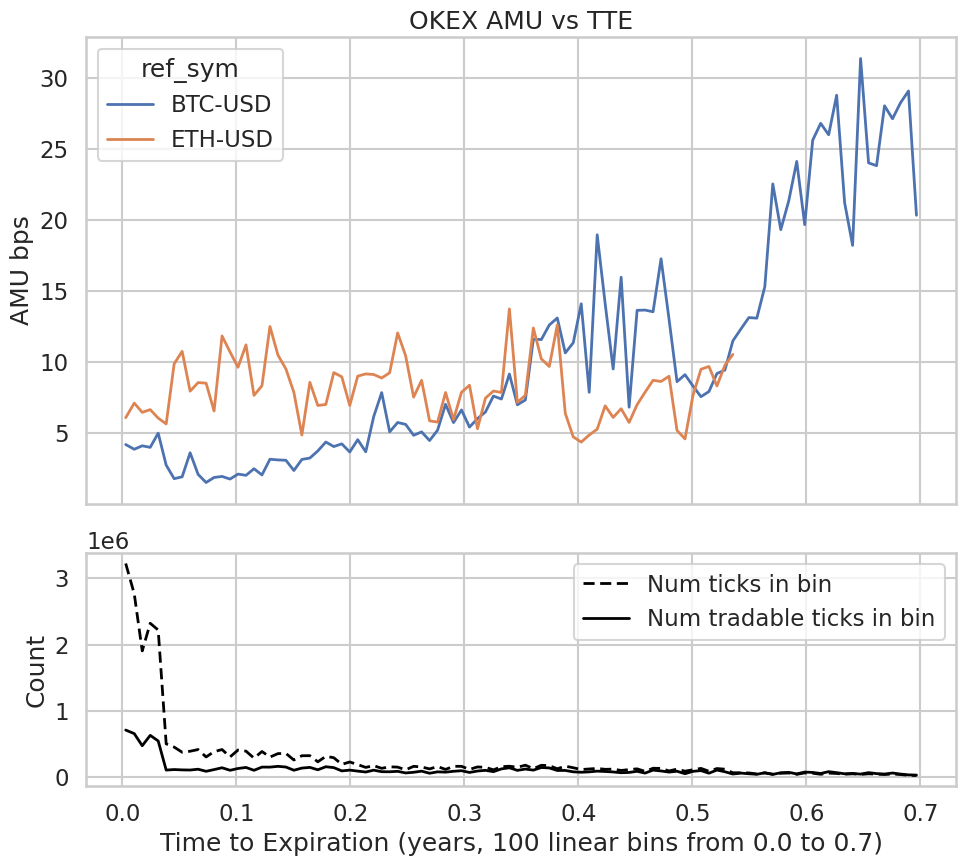

In [4]:
def plot_amu_bps_by_tte(
    pcpb,
    max_bp_cutoff=100,
    tte_from=0.0,
    tte_to=0.7,
    n_bins=100,
    filename="publications/okex_amu_bps_by_tte.png",
    title="OKEX AMU bps vs TTE",
):
    use_cols = ["ref_sym", "tte", "fwd_call", "bck_call", "bck_put", "fwd_put"]
    tmp = (
        pcpb[use_cols]
        .assign(tte=lambda d: pd.to_numeric(d["tte"], errors="coerce"))
        .dropna(subset=["tte", "ref_sym"])
        .loc[lambda d: d["tte"].between(tte_from, tte_to)]
        .copy()
    )

    tte_edges = np.linspace(tte_from, tte_to, n_bins + 1)
    tmp["tte_bin"] = pd.cut(tmp["tte"], bins=tte_edges, include_lowest=True)

    # Vectorized equivalent of calculate_amu_bps per group
    tmp["fwd_call_clip"] = tmp["fwd_call"].clip(lower=0, upper=max_bp_cutoff)
    tmp["bck_call_clip"] = tmp["bck_call"].clip(lower=0, upper=max_bp_cutoff)
    tmp["bck_put_clip"] = tmp["bck_put"].clip(lower=0, upper=max_bp_cutoff)
    tmp["fwd_put_clip"] = tmp["fwd_put"].clip(lower=0, upper=max_bp_cutoff)

    tmp["fwd_call_pos"] = (tmp["fwd_call"] > 0).astype(int)
    tmp["bck_call_pos"] = (tmp["bck_call"] > 0).astype(int)
    tmp["bck_put_pos"] = (tmp["bck_put"] > 0).astype(int)
    tmp["fwd_put_pos"] = (tmp["fwd_put"] > 0).astype(int)

    grouped = (
        tmp.groupby(["ref_sym", "tte_bin"], sort=True)
        .agg(
            fwd_call_bp=("fwd_call_clip", "mean"),
            bck_call_bp=("bck_call_clip", "mean"),
            bck_put_bp=("bck_put_clip", "mean"),
            fwd_put_bp=("fwd_put_clip", "mean"),
            fwd_call_num=("fwd_call_pos", "sum"),
            bck_call_num=("bck_call_pos", "sum"),
            bck_put_num=("bck_put_pos", "sum"),
            fwd_put_num=("fwd_put_pos", "sum"),
            num_pairs=("tte", "size"),
        )
        .reset_index()
    )

    grouped["num_amu"] = (
        grouped["fwd_call_num"]
        + grouped["bck_call_num"]
        + grouped["bck_put_num"]
        + grouped["fwd_put_num"]
    )
    grouped["weighted_sum"] = (
        grouped["fwd_call_bp"] * grouped["fwd_call_num"]
        + grouped["bck_call_bp"] * grouped["bck_call_num"]
        + grouped["bck_put_bp"] * grouped["bck_put_num"]
        + grouped["fwd_put_bp"] * grouped["fwd_put_num"]
    )
    grouped["amu_bps"] = grouped["weighted_sum"] / grouped["num_amu"].replace(0, np.nan)

    curve_df = grouped[["ref_sym", "tte_bin", "amu_bps", "num_amu", "num_pairs"]].copy()
    curve_df["tte_bin"] = curve_df["tte_bin"].astype("object")
    curve_df["tte_bin_center"] = curve_df["tte_bin"].map(
        lambda iv: iv.mid if isinstance(iv, pd.Interval) else np.nan
    )
    curve_df = curve_df.sort_values(["ref_sym", "tte_bin_center"])

    counts_df = (
        curve_df.groupby("tte_bin_center", sort=True)[["num_amu", "num_pairs"]]
        .sum()
        .reset_index()
    )
    counts_long = counts_df.melt(
        id_vars="tte_bin_center",
        value_vars=["num_amu", "num_pairs"],
        var_name="metric",
        value_name="count",
    )
    counts_long["metric"] = counts_long["metric"].map(
        {
            "num_amu": "Num tradable ticks in bin",
            "num_pairs": "Num ticks in bin",
        }
    )

    sns.set_theme(style="whitegrid", context="talk")
    fig, (ax_top, ax_bottom) = plt.subplots(
        2,
        1,
        figsize=(10, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
    )

    sns.lineplot(
        data=curve_df,
        x="tte_bin_center",
        y="amu_bps",
        hue="ref_sym",
        linewidth=2.0,
        palette="deep",
        ax=ax_top,
    )
    ax_top.set_ylabel("AMU bps")
    ax_top.set_title(title)
    ax_top.legend(title="ref_sym", loc="best")

    sns.lineplot(
        data=counts_long,
        x="tte_bin_center",
        y="count",
        hue="metric",
        style="metric",
        linewidth=2.0,
        palette={
            "Num tradable ticks in bin": "black",
            "Num ticks in bin": "black",
        },
        dashes={
            "Num tradable ticks in bin": "",
            "Num ticks in bin": (4, 2),
        },
        ax=ax_bottom,
    )
    ax_bottom.set_xlabel("Time to Expiration (years, 100 linear bins from 0.0 to 0.7)")
    ax_bottom.set_ylabel("Count")
    handles, labels = ax_bottom.get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))
    ordered_labels = ["Num ticks in bin", "Num tradable ticks in bin"]
    ordered_handles = [label_to_handle[label] for label in ordered_labels if label in label_to_handle]
    ax_bottom.legend(ordered_handles, ordered_labels, title="")

    fig.tight_layout()
    fig.savefig(filename)

    return curve_df, counts_df, fig, (ax_top, ax_bottom)


amu_by_tte = tte_counts = tte_fig = tte_axes = None
if execute and pcpb is not None:

    amu_by_tte, tte_counts, tte_fig, tte_axes = plot_amu_bps_by_tte(
        pcpb,
        filename="publications/okex_amu_bps_by_tte.png",
        title="OKEX AMU vs TTE",
    )